# Analisis Sentimen Ulasan Destinasi Wisata di Madura Menggunakan IndoBertweet dan Indobert

## 1. Import Libraries

In [216]:
import os
import gc
import time
import re
import string
import socket
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # Diimpor dari torch agar aman dari ImportError
from torch.cuda.amp import autocast, GradScaler

import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Matikan semua log peringatan pengganggu secara global
warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()


print(f"Status Ketersediaan GPU: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nama GPU Aktif: {torch.cuda.get_device_name(0)}")

Status Ketersediaan GPU: True
Nama GPU Aktif: Tesla T4


## 2. Load data

In [217]:
# Buka gembok batasan baris milik pandas (None artinya tanpa batas)
pd.set_option('display.max_rows', None)

# Load dataset tempat
df_place = pd.read_csv('/kaggle/input/datasets/nicodwiputra/data-tempat/all-task-39-overview.csv')

print("Kolom:", df_place.columns.tolist())
print(f"\nJumlah tempat: {len(df_place)}")
print(f"\nKategori unik (Semua Ditampilkan):")

# Tinggal print biasa, otomatis keluar semua dari atas sampai bawah
print(df_place['main_category'].value_counts())

Kolom: ['place_id', 'name', 'description', 'is_spending_on_ads', 'reviews', 'rating', 'competitors', 'website', 'phone', 'can_claim', 'owner_name', 'owner_profile_link', 'featured_image', 'main_category', 'categories', 'workday_timing', 'is_temporarily_closed', 'closed_on', 'address', 'review_keywords', 'link', 'query']

Jumlah tempat: 872

Kategori unik (Semua Ditampilkan):
main_category
Tujuan Wisata                          208
Biro Perjalanan dan Wisata             102
Hotel                                   57
Kantor Perusahaan                       39
Agen Sewa Mobil                         34
Pondok                                  27
Layanan Transportasi                    26
Penginapan                              18
Rumah wisata                            17
Hostel                                  14
Minimarket                              14
Bengkel Sepeda Motor                    13
Pom bensin/SPBU                         11
Biro Wisata                             10
Motel 

In [218]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/nicodwiputra/review-wisata/all-task-39-detailed-reviews.csv')

print("✅ Dataset berhasil dimuat!")
print(f"Shape: {df.shape}")
print(f"\nKolom ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}")

✅ Dataset berhasil dimuat!
Shape: (94209, 25)

Kolom (25):
  - place_id
  - place_name
  - review_id
  - review_link
  - name
  - reviewer_id
  - reviewer_profile
  - rating
  - review_text
  - original_language
  - review_translated_text
  - translated_language
  - published_at
  - published_at_date
  - response_from_owner_text
  - response_from_owner_ago
  - response_from_owner_date
  - response_from_owner_translated_text
  - avatar_link
  - total_number_of_reviews_by_reviewer
  - total_number_of_photos_by_reviewer
  - is_local_guide
  - experience_details
  - review_photos
  - review_origin


## 3. Cek Missing Values

In [219]:
# Lihat sample data
print("=== 5 Baris Pertama ===")
display(df.head())

print("\n=== Info Dataset ===")
df.info()

print("\n=== Distribusi Rating ===")
print(df['rating'].value_counts().sort_index())

print("\n=== Missing Values ===")
print(df[['review_text', 'rating', 'original_language']].isnull().sum())

=== 5 Baris Pertama ===


,place_id,place_name,review_id,review_link,name,reviewer_id,reviewer_profile,rating,review_text,original_language,...,response_from_owner_ago,response_from_owner_date,response_from_owner_translated_text,avatar_link,total_number_of_reviews_by_reviewer,total_number_of_photos_by_reviewer,is_local_guide,experience_details,review_photos,review_origin
0,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,ChZDSUhNMG9nS0VJQ0FnSUNadTVxTUt3EAE,https://www.google.com/maps/reviews/data=!4m8!...,Dimas Nurdian Syah Wahyudi,117740383702575191413,https://www.google.com/maps/contrib/1177403837...,4.0,NaN,NaN,...,Edited a week ago,2023-10-10T11:10:37,Dear Mr. Dimas Nurdian Syah Wahyudi.\n\nWarm g...,https://lh3.googleusercontent.com/a/ACg8ocKusK...,97,27,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...",[],google
1,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2xwMlVWQmFXRU0zZFhWQ2...,https://www.google.com/maps/reviews/data=!4m8!...,Rifka Faradisa,100422181349461110397,https://www.google.com/maps/contrib/1004221813...,5.0,NaN,NaN,...,3 weeks ago,2026-01-14T01:07:22,Dear Mrs. Rifka Faradisa\n\nA warm greeting fr...,https://lh3.googleusercontent.com/a/ACg8ocLNOL...,15,7,1.0,[],[],google
2,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2w5VE1HTlFhRWh5V0ZneF...,https://www.google.com/maps/reviews/data=!4m8!...,nugroho suksmanto,101113277062498619143,https://www.google.com/maps/contrib/1011132770...,5.0,NaN,NaN,...,3 weeks ago,2026-01-14T01:06:57,Dear Mr. Nugroho Suksmanto\n\nA warm greeting ...,https://lh3.googleusercontent.com/a/ACg8ocKpiB...,0,0,NaN,[],[],google
3,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2pKWE5YRldkMTluYkhaUG...,https://www.google.com/maps/reviews/data=!4m8!...,eric,109528954650929435012,https://www.google.com/maps/contrib/1095289546...,5.0,Trip Pertama 2026\nSumenep - Pamekasan\nHoteln...,id,...,3 weeks ago,2026-01-09T02:11:58,Dear Mr. Eric\n\nA warm greeting from FrontOne...,https://lh3.googleusercontent.com/a-/ALV-UjUj8...,169,424,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...","[{""id"":""CIABIhBlam7tesEKr2x8AXvz2aTG"",""url"":""h...",google
4,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2kxT1REUXphbTFoWjB0RF...,https://www.google.com/maps/reviews/data=!4m8!...,Rizky Afreza Febryanto,117434415881649210216,https://www.google.com/maps/contrib/1174344158...,5.0,Sangat menyenangkan menginap di hotel Front On...,id,...,3 weeks ago,2026-01-09T02:11:36,Dear Mr. Rizky Afreza\n\nA warm greeting from ...,https://lh3.googleusercontent.com/a-/ALV-UjUJd...,1034,6779,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...",[],google



=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94209 entries, 0 to 94208
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   place_id                             94209 non-null  object 
 1   place_name                           94209 non-null  object 
 2   review_id                            94209 non-null  object 
 3   review_link                          94209 non-null  object 
 4   name                                 94209 non-null  object 
 5   reviewer_id                          94068 non-null  object 
 6   reviewer_profile                     94209 non-null  object 
 7   rating                               94068 non-null  float64
 8   review_text                          48765 non-null  object 
 9   original_language                    48784 non-null  object 
 10  review_translated_text               44377 non-null  object 
 11  transl

## 4. Drop Missing Values & Saring Kategori Wisata

In [220]:
# 1. Ambil kolom ulasan esensial
cols_needed = ['place_id', 'place_name', 'rating', 'review_text', 'original_language', 'published_at_date']
df_clean = df[cols_needed].copy().dropna(subset=['review_text', 'rating'])

# 2. Muat dataset ikhtisar untuk membaca kategori tempat
df_place = pd.read_csv('/kaggle/input/datasets/nicodwiputra/data-tempat/all-task-39-overview.csv')

# 3. 🎯 EXTENDED FILTER KATEGORI (Mencakup semua objek wisata & akomodasi riil di Madura)
kategori_wisata = [
    # --- Atraksi & Destinasi Wisata ---
    'Tujuan Wisata', 'Pantai', 'Pantai Umum', 'Bangunan Bersejarah', 'Museum', 
    'Taman Kota', 'Taman', 'Monumen', 'Area Rekreasi Alam', 'Taman Rekreasi Air', 
    'Tempat Ziarah', 'Pusat Kesenian', 'Area Mendaki', 'Hutan Nasional', 
    'Peternakan wisata', 'Toko Suvenir', 'Toko pakaian batik',
    
    # --- Akomodasi & Penginapan ---
    'Hotel', 'Pondok', 'Penginapan', 'Rumah wisata', 'Hostel', 
    'Hotel jangka panjang', 'Rumah Pondokan', 'Penginapan religi', 
    'Apartemen sewa liburan', 'Pondok pedesaan', 'Pondok Pegunungan', 
    'Penginapan Dalam Ruangan', 'Hotel Resor', 'Rumah berlibur', 'Bed & Breakfast',
    
    # --- Layanan & Agensi Tour ---
    'Biro Perjalanan dan Wisata', 'Biro Wisata', 'Penyelenggara Perjalanan', 
    'Pusat Informasi Pariwisata', 'Agensi wisata olahraga', 'Biro Wisata Bawah Laut', 
    'Agen Tur Kapal', 'Agen Tur Bus', 'Operator wahana parasailing', 'Bumi perkemahan'
]

# 4. Amankan data ulasan pariwisata final
place_wisata_ids = df_place[df_place['main_category'].isin(kategori_wisata)]['place_id']
df_tourist = df_clean[df_clean['place_id'].isin(place_wisata_ids)].copy()

print("=== HASIL FILTERING KATEGORI WISATA===")
print(f"Jumlah data awal       : {len(df_clean):,} baris")
print(f"Jumlah data pariwisata : {len(df_tourist):,} baris")

=== HASIL FILTERING KATEGORI WISATA===
Jumlah data awal       : 48,624 baris
Jumlah data pariwisata : 34,974 baris


## 5. Filter Bahasa Indonesia & Visualisasi Distribusi Rating

Total review tempat wisata khusus bahasa Indonesia: 31,134 baris

=== Distribusi Rating Tempat Wisata (Bahasa Indonesia) ===
rating
1.0     1658
2.0     1072
3.0     3492
4.0     6292
5.0    18620
Name: count, dtype: int64


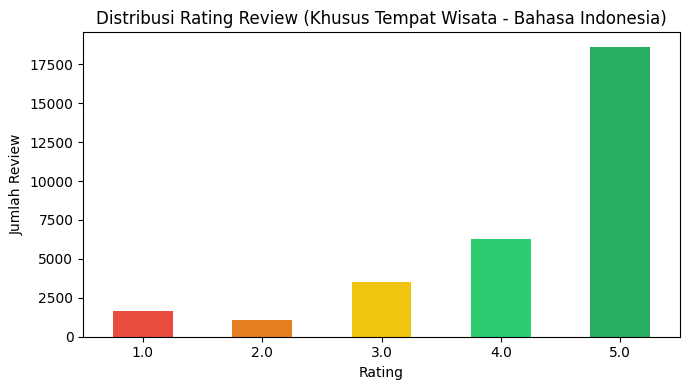

In [221]:
# Filter khusus ulasan bahasa Indonesia
df_id = df_tourist[df_tourist['original_language'] == 'id'].copy()
df_id = df_id.reset_index(drop=True)

print(f"Total review tempat wisata khusus bahasa Indonesia: {len(df_id):,} baris")

print("\n=== Distribusi Rating Tempat Wisata (Bahasa Indonesia) ===")
print(df_id['rating'].value_counts().sort_index())

# Visualisasi distribusi rating setelah pembersihan kategori
plt.figure(figsize=(7,4))
df_id['rating'].value_counts().sort_index().plot(kind='bar', color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
plt.title('Distribusi Rating Review (Khusus Tempat Wisata - Bahasa Indonesia)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Text Preprocessing

In [222]:
import pandas as pd
import re
import string

# 1. Muat file kamus kata baku gaul dari input Kaggle kamu
# (⚠️ Pastikan ganti path di bawah ini sesuai dengan lokasi file di Kaggle kamu)
path_kamus_baku = '/kaggle/input/datasets/nicodwiputra/normalisasi-slangtypo/kamuskatabaku (1).csv'
df_slang = pd.read_csv(path_kamus_baku)

# 2. Konversikan kolom 'slang' dan 'formal' secara otomatis menjadi dictionary Python
kamus_normalisasi = dict(zip(df_slang['slang'], df_slang['formal']))

# # 3. Ruang Tambahan (Overrides): Masukkan kata khusus domain pariwisata yang belum tercover di file
# kamus_tambahan_wisata = {
#     'gajelas': 'tidak jelas',
#     'mhalan': 'mahalan',
#     'pungkli': 'pungli',
#     'ktr': 'kotor'
# }
# # Gabungkan kamus utama dengan kamus tambahan pariwisata
# kamus_normalisasi.update(kamus_tambahan_wisata)

# 4. Fungsi Preprocessing Terpadu
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # Bersihkan tautan/URL
    text = re.sub(r'@\w+|#\w+', '', text)         # Bersihkan mention/tagar
    text = re.sub(r'\d+', '', text)               # Bersihkan angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # Bersihkan simbol/tanda baca

    # Fitur A: Normalisasi kata memanjang (e.g., "baguuuss" -> "bagus")
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Fitur B: Normalisasi Slang & Typo Massal dari Berkas Excel/CSV
    words = text.split()
    words_normalized = [kamus_normalisasi[word] if word in kamus_normalisasi else word for word in words]
    text = " ".join(words_normalized)

    text = re.sub(r'\s+', ' ', text).strip()      # Bersihkan spasi berlebih
    return text

# 5. Eksekusi pembersihan teks pada dataset ulasan utama
df_id['clean_text'] = df_id['review_text'].apply(preprocess)

print(f"✅ Sukses memuat {len(kamus_normalisasi):,} kata normalisasi typo")
print("✅ Tahap Pre-processing data teks pariwisata selesai dengan aman!")

✅ Sukses memuat 4,344 kata normalisasi typo
✅ Tahap Pre-processing data teks pariwisata selesai dengan aman!


In [223]:
print("=== CONTOH PREPROCESSING ===")

for i in range(10):
    print(f"\nData ke-{i+1}")
    print("Asli  :", df_id['review_text'].iloc[i])
    print("Bersih:", df_id['clean_text'].iloc[i])

=== CONTOH PREPROCESSING ===

Data ke-1
Asli  : Trip Pertama 2026
Sumenep - Pamekasan
Hotelnya menyenangkan, bagus dan tanpa keluhan. Next klo liburan sama anak anak pasti pilih hotel ini, tq Front One 👍👍
Bersih: trip pertama sumenep pamekasan hotelnya menyenangkan bagus dan tanpa keluhan next kalau liburan sama anak anak pasti pilih hotel ini tq front one 👍👍

Data ke-2
Asli  : Sangat menyenangkan menginap di hotel Front One Pamekasan bersama keluarga.
Bersih: sangat menyenangkan menginap di hotel front one pamekasan bersama keluarga

Data ke-3
Asli  : Fun
Bersih: fun

Data ke-4
Asli  : Kalo ke pamekasan nginepnya y disini
Bersih: kalau ke pamekasan nginepnya ya disini

Data ke-5
Asli  : Rekomen deh nginep disini. Lokasinya strategis enak mau kemana”. Breakfast menunya juga banyak dan bervariatif. Fasilitas nyaman dan lengkap 💕
Bersih: rekomen deh nginep disini lokasinya strategis enak mau kemana” breakfast menunya juga banyak dan bervariatif fasilitas nyaman dan lengkap 💕

Data ke-6
A

In [224]:
df_id['panjang_asli'] = df_id['review_text'].astype(str).apply(lambda x: len(x.split()))
df_id['panjang_bersih'] = df_id['clean_text'].astype(str).apply(lambda x: len(x.split()))

print("=== RATA-RATA PANJANG TEKS ===")
print(f"Sebelum preprocessing : {df_id['panjang_asli'].mean():.2f} kata")
print(f"Sesudah preprocessing : {df_id['panjang_bersih'].mean():.2f} kata")

=== RATA-RATA PANJANG TEKS ===
Sebelum preprocessing : 13.14 kata
Sesudah preprocessing : 12.94 kata


In [225]:
vocab_asli = set(
    " ".join(df_id['review_text'].astype(str).str.lower()).split()
)

vocab_bersih = set(
    " ".join(df_id['clean_text']).split()
)

print("=== UKURAN KOSAKATA ===")
print(f"Kosakata sebelum preprocessing : {len(vocab_asli):,}")
print(f"Kosakata sesudah preprocessing : {len(vocab_bersih):,}")

=== UKURAN KOSAKATA ===
Kosakata sebelum preprocessing : 39,406
Kosakata sesudah preprocessing : 24,708


In [226]:
from collections import Counter

top_words = Counter(
    " ".join(df_id['clean_text']).split()
).most_common(20)

df_top = pd.DataFrame(
    top_words,
    columns=['kata', 'frekuensi']
)

display(df_top)

,kata,frekuensi
0,yang,10723
1,dan,10486
2,di,8377
3,bagus,7347
4,untuk,5631
5,tempat,5525
6,ada,4903
7,sangat,3445
8,dengan,3321
9,juga,3232


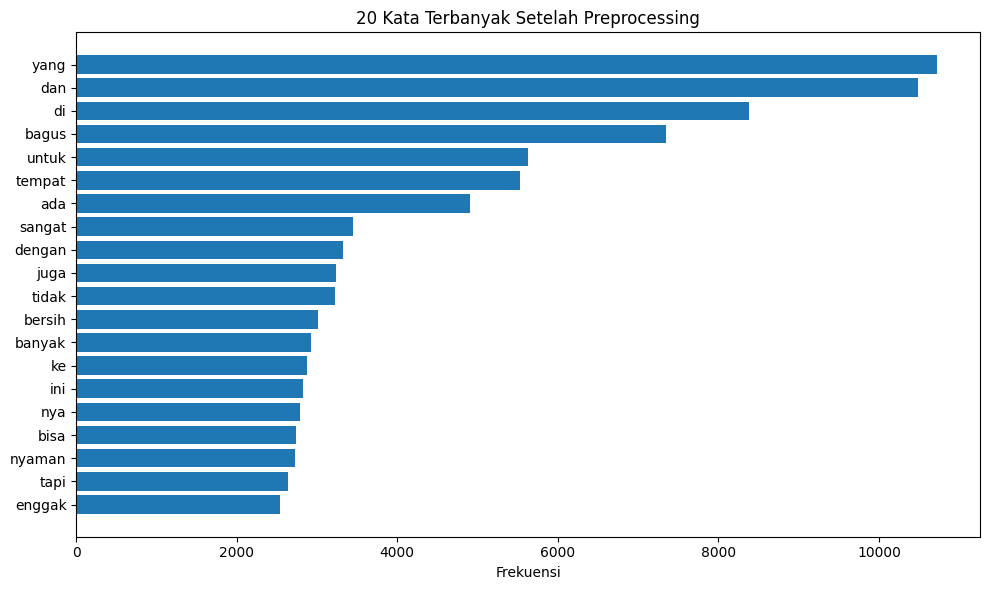

In [227]:
plt.figure(figsize=(10,6))

plt.barh(
    df_top['kata'][::-1],
    df_top['frekuensi'][::-1]
)

plt.title("20 Kata Terbanyak Setelah Preprocessing")
plt.xlabel("Frekuensi")
plt.tight_layout()
plt.show()

## 7. Kandidat Leksikon

In [228]:
# import re
# import pandas as pd
# from collections import Counter

# # 1. Hitung frekuensi kemunculan kata di teks bersih
# semua_kata = " ".join(df_id['clean_text']).split()
# hitung_frekuensi = Counter(semua_kata)

# data_kandidat = []
# print("⏳ Menghitung statistik distribusi rating kata (Metode SentiDraw)...")

# # 2. Cari hubungan probabilitas kata terhadap distribusi rating ulasan
# for kata, frekuensi in hitung_frekuensi.items():
#     if frekuensi >= 10: 
#         # Melakukan re.escape agar karakter khusus aman saat pencarian regex kata utuh
#         ulasan_terkait = df_id[df_id['clean_text'].str.contains(rf'\b{re.escape(kata)}\b', regex=True, na=False)]
        
#         if len(ulasan_terkait) > 0:
#             # 🎯 ADAPTASI UTAMA SENTIDRAW: Hitung distribusi probabilitas tiap tingkatan bintang
#             rating_counts = ulasan_terkait['rating'].value_counts()
            
#             p1 = rating_counts.get(1, 0)
#             p2 = rating_counts.get(2, 0)
#             p3 = rating_counts.get(3, 0)
#             p4 = rating_counts.get(4, 0)
#             p5 = rating_counts.get(5, 0)
            
#             total = p1 + p2 + p3 + p4 + p5
            
#             # Ubah frekuensi menjadi nilai probabilitas riil (0 s.d 1)
#             p1 /= total
#             p2 /= total
#             p3 /= total
#             p4 /= total
#             p5 /= total
            
#             # Rumus Semantic Orientation (SO) Score SentiDraw berbasis pembobotan probabilitas
#             so_score = ((-2 * p1) + (-1 * p2) + (0 * p3) + (1 * p4) + (2 * p5))
            
#             # Normalisasi nilai dari rentang SO (-2 s.d 2) menjadi skala leksikon (-5 s.d 5)
#             bobot_otomatis = round(so_score * 2.5)
#             bobot_otomatis = int(max(-5, min(5, bobot_otomatis))) # Kunci di batas aman integer
            
#             # Simpan data kandidat (tetap menggunakan nama kolom 'bobot_inset' agar Cell 8 & 9 tidak error)
#             data_kandidat.append({
#                 'kata': kata, 
#                 'frekuensi': frekuensi,
#                 'rata_rating_asal': round(ulasan_terkait['rating'].mean(), 2), 
#                 'so_score_raw': round(so_score, 4),
#                 'bobot_inset': bobot_otomatis
#             })

# df_kamus_otomatis = pd.DataFrame(data_kandidat)
# print(f"✅ Sistem berhasil mengekstrak {len(df_kamus_otomatis):,} kata kandidat potensial dengan distribusi SentiDraw.")

In [ ]:
import re
import pandas as pd
from collections import Counter

# 1. Hitung frekuensi kemunculan kata di teks bersih
semua_kata = " ".join(df_id['clean_text']).split()
hitung_frekuensi = Counter(semua_kata)

# 🎯 KUNCI UTAMA: Hitung rata-rata rating riil seluruh dataset kamu (Baseline)
rata_rating_dataset = df_id['rating'].mean() 
print(f"📊 Rata-rata rating baseline dataset kamu: {rata_rating_dataset:.3f}")

data_kandidat = []
print("⏳ Menghitung statistik hubungan kata kandidat leksikon...")

# 2. Cari hubungan kata terhadap rating agregat dengan skala relatif
for kata, frekuensi in hitung_frekuensi.items():
    if frekuensi >= 10: 
        # Melakukan re.escape agar karakter khusus aman saat pencarian regex kata utuh
        ulasan_terkait = df_id[df_id['clean_text'].str.contains(rf'\b{re.escape(kata)}\b', regex=True, na=False)]
        
        if len(ulasan_terkait) > 0:
            rata_rating = ulasan_terkait['rating'].mean()
            
            # 🛠️ RUMUS BARU: Menghilangkan bias dominasi rating bintang 5
            if rata_rating >= rata_rating_dataset:
                # Rentang antara rata-rata dataset s.d 5.0 diubah menjadi skala 0 s.d 5
                bobot_otomatis = ((rata_rating - rata_rating_dataset) / (5.0 - rata_rating_dataset)) * 5
            else:
                # Rentang antara 1.0 s.d rata-rata dataset diubah menjadi skala -5 s.d 0
                bobot_otomatis = ((rata_rating - rata_rating_dataset) / (rata_rating_dataset - 1.0)) * 5
                
            bobot_otomatis = int(round(bobot_otomatis))
            bobot_otomatis = max(-5, min(5, bobot_otomatis)) # Kunci di batas aman
            
            data_kandidat.append({
                'kata': kata, 'frekuensi': frekuensi,
                'rata_rating_asal': round(rata_rating, 2), 'bobot_inset': bobot_otomatis
            })

df_kamus_otomatis = pd.DataFrame(data_kandidat)
print(f"✅ Sistem berhasil menemukan {len(df_kamus_otomatis):,} kata kandidat potensial.")

📊 Rata-rata rating baseline dataset kamu: 4.257
⏳ Menghitung statistik hubungan kata kandidat leksikon...


## 8. Kamus Lexicon

In [ ]:
# Saring kata yang murni punya muatan emosi (bobot tidak sama dengan 0)
kamus_final = df_kamus_otomatis[df_kamus_otomatis['bobot_inset'] != 0].copy()
kamus_final = kamus_final.sort_values(by='bobot_inset', ascending=False).reset_index(drop=True)

# Ekspor berkas CSV kamus untuk lampiran berkas Tugas Akhir
kamus_final.to_csv('custom_inset_lexicon.csv', index=False)
print("💾 Berkas 'custom_inset_lexicon.csv'")

# print("\n🔥 SANGKUTAN KATA POSITIF TERATAS:")
# display(kamus_final.head(10))

# print("\n❄️ SANGKUTAN KATA NEGATIF TERATAS:")
# display(kamus_final.tail(10))

In [ ]:
print(kamus_final['bobot_inset'].value_counts().sort_index())

plt.figure(figsize=(8,5))

kamus_final['bobot_inset'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Distribusi Bobot Leksikon Otomatis')
plt.xlabel('Bobot Sentimen')
plt.ylabel('Jumlah Kata')
plt.tight_layout()
plt.show()

In [ ]:
print("=== TOP 20 POSITIF ===")
display(
    kamus_final.sort_values(
        'bobot_inset',
        ascending=False
    ).head(20)
)

print("=== TOP 20 NEGATIF ===")
display(
    kamus_final.sort_values(
        'bobot_inset'
    ).head(20)
)

## 9. Labelling

In [ ]:
# Transformasikan DataFrame kamus menjadi dictionary pemetaan cepat
kamus_inset_custom = dict(zip(kamus_final['kata'], kamus_final['bobot_inset']))

def hitung_sentimen_murni_leksikon(text):
    words = str(text).split()
    total_skor = 0

    kata_negasi = {
        'tidak', 'tak', 'bukan',
        'gak', 'ga', 'nggak', 'enggak'
    }

    for i, word in enumerate(words):

        if word in kamus_inset_custom:
            skor = kamus_inset_custom[word]

            # cek 2 kata sebelumnya
            window_awal = max(0, i - 2)
            konteks = words[window_awal:i]

            if any(kata in kata_negasi for kata in konteks):
                skor = -skor

            total_skor += skor

    if total_skor > 0:
        return 'positif'
    elif total_skor < 0:
        return 'negatif'
    else:
        return 'netral'

# Eksekusi penentuan label kelas target sentimen ulasan
df_id['label'] = df_id['clean_text'].apply(hitung_sentimen_murni_leksikon)

print("=== DISTRIBUSI KELAS SENTIMEN DATASET BARU ===")
print(df_id['label'].value_counts())

print("\nSampel Hasil Pelabelan:")
display(df_id[['clean_text', 'label']].head(10))

In [ ]:
print(kamus_final['bobot_inset'].value_counts().sort_index())

In [ ]:
df_id[df_id['label']=='positif'][['clean_text']].sample(30)

In [ ]:
df_id[df_id['label']=='negatif'][['clean_text']].head(70)

In [ ]:
for kata in ['bagus','indah','mantap','kotor','kecewa','mahal','pantai','wisata','tempat']:
    print(kata, kamus_inset_custom.get(kata))

## 10. Split Data

In [ ]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (teks bersih) dan target (label sentimen)
X = df_id['clean_text'].values
y = df_id['label'].map({'negatif': 0, 'netral': 1, 'positif': 2}).values

# Split pertama: 80% Train, 20% Temporary (untuk Val & Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Split kedua: Bagi data temporary menjadi 50% Validation dan 50% Testing (masing-masing 10% dari total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"📊 Ukuran Data Latih (Train) : {X_train.shape[0]:,} sampel")
print(f"📊 Ukuran Data Validasi (Val) : {X_val.shape[0]:,} sampel")
print(f"📊 Ukuran Data Uji (Test)     : {X_test.shape[0]:,} sampel")

## 11. Menghitung Bobot Kelas (Class Weights)

In [ ]:
import torch
from sklearn.utils.class_weight import compute_class_weight

# Hitung bobot kelas secara otomatis menggunakan scikit-learn
weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

# Konversikan menjadi PyTorch Tensor agar siap dimasukkan ke fungsi Loss (CrossEntropyLoss)
class_weights = torch.tensor(weights, dtype=torch.float)

print("=== BOBOT PENALTI KELAS (CLASS WEIGHTS) ===")
print(f" - Bobot Kelas 0 [Negatif] : {class_weights[0].item():.4f}")
print(f" - Bobot Kelas 1 [Netral]  : {class_weights[1].item():.4f}")
print(f" - Bobot Kelas 2 [Positif] : {class_weights[2].item():.4f}")

## 12. Modelling

### 12.1. Tokenizer

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

class UlasanPariwisataDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

def siapkan_dataloader(model_name, X_train, X_val, X_test, y_train, y_val, y_test, batch_size=16):
    print(f"⏳ Memuat Tokenizer untuk: {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    
    MAX_LEN = 128
    print("⏳ Melakukan tokenisasi korpus teks...")
    train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=MAX_LEN)
    val_encodings   = tokenizer(list(X_val), truncation=True, padding=True, max_length=MAX_LEN)
    test_encodings  = tokenizer(list(X_test), truncation=True, padding=True, max_length=MAX_LEN)
    
    train_dataset = UlasanPariwisataDataset(train_encodings, y_train)
    val_dataset   = UlasanPariwisataDataset(val_encodings, y_val)
    test_dataset  = UlasanPariwisataDataset(test_encodings, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"✅ DataLoader untuk {model_name} SIAP!\n")
    return train_loader, val_loader, test_loader

### 12.2. Batch

In [ ]:
import os
import copy
import time
import gc
import torch
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW  
from torch.cuda.amp import autocast, GradScaler

def train_dan_evaluasi_model(model_name, train_loader, val_loader, class_weights, epochs=10, lr=1e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Memulai Pemodelan untuk: {model_name}")
    
    # 1. Inisialisasi Model
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    model.to(device)
    
    # Loss Function dengan Bobot Penalti Kelas
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))
    
    # Optimizer dengan weight decay tingkat lanjut untuk menekan overfitting
    optimizer = AdamW(model.parameters(), lr=lr)
    
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=int(0.1 * total_steps), 
        num_training_steps=total_steps
    )
    scaler = GradScaler()
    
    # --- Variabel Pelacak Model Terbaik ---
    best_val_loss = float('inf')
    best_model_weights = None
    best_epoch = 1
    # Buat nama file save yang aman dari karakter path/slug
    nama_file_save = f"best_model_{model_name.replace('/', '_')}.pt"
    
    # 2. Training Loop
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_train_loss += loss.item()
            
        # 3. Validation Tahap
        model.eval()
        total_val_loss = 0
        preds_all, labels_all = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                with autocast():
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss = criterion(outputs.logits, labels)
                    
                total_val_loss += loss.item()
                preds = torch.argmax(outputs.logits, dim=1).flatten().cpu().numpy()
                preds_all.extend(preds)
                labels_all.extend(labels.cpu().numpy())
                
        # Hitung Rata-rata Loss dan Metrik
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        acc = accuracy_score(labels_all, preds_all)
        macro_f1 = f1_score(labels_all, preds_all, average='macro')
        
        # --- Logika Penyimpanan Bobot Terbaik ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            # Menggandakan bobot state_dict ke memori CPU agar hemat VRAM saat looping berjalan
            best_model_weights = copy.deepcopy(model.state_dict())
            # Simpan juga ke Google Colab drive/lokal sebagai backup aman
            torch.save(best_model_weights, nama_file_save)
            status_save = f"✅ Model terbaik disimpan (Loss Val turun)"
        else:
            status_save = f"⚠️ Loss Val tidak membaik"
            
        print(f" Epoch [{epoch+1}/{epochs}] | Loss Latih: {avg_train_loss:.4f} | Loss Val: {avg_val_loss:.4f} | Acc Val: {acc*100:.2f}% | Macro F1 Val: {macro_f1*100:.2f}% | {status_save}")
        
    print(f"\n🏆 Proses Selesai! Mengembalikan model terbaik dari Epoch {best_epoch} dengan Loss Val: {best_val_loss:.4f}")
    
    # Memuat kembali bobot terbaik ke dalam model sebelum dikembalikan ke pipeline utama
    model.load_state_dict(best_model_weights)
    return model

### 12.3. Training Model

In [ ]:
import transformers
transformers.logging.set_verbosity_error()

In [ ]:
# List model yang akan dibandingkan sesuai repositori resmi Hugging Face
daftar_model = {
    'IndoBERT (indolem/indobert-base-uncased)': 'indolem/indobert-base-uncased',
    'IndoBERTweet (indolem/indobertweet-base-uncased)': 'indolem/indobertweet-base-uncased'
}

model_terlatih_dict = {}

for nama_label, path_model in daftar_model.items():
    print(f"\n==================================================================")
    print(f"⚙️ MEMULAI PIPELINE UNTUK: {nama_label}")
    print(f"==================================================================")
    
    # 1. Siapkan Dataloader spesifik untuk model tersebut
    train_ld, val_ld, test_ld = siapkan_dataloader(
        path_model, X_train, X_val, X_test, y_train, y_val, y_test, batch_size=16
    )
    
    # 2. Jalankan Fine-Tuning (Fungsi baru otomatis mengembalikan bobot terbaik dari epoch optimal)
    model_hasil = train_dan_evaluasi_model(
        path_model, train_ld, val_ld, class_weights, epochs=10, lr=1e-5
    )
    
    # 3. Simpan model terbaik ke dictionary untuk evaluasi akhir/bukan model epoch terakhir
    model_terlatih_dict[nama_label] = {
        'model': model_hasil,
        'test_loader': test_ld
    }
    
    # 4. MANAJEMEN MEMORI GPU (Pencegahan OOM/Crash)
    del model_hasil, train_ld, val_ld, test_ld
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"✨ Sesi untuk {nama_label} selesai & Memori GPU dibersihkan.\n")

### 12.4. Testing



In [ ]:
from tqdm.auto import tqdm
# 🎯 Tambahan import classification_report di sini
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import torch
from torch.cuda.amp import autocast

hasil_komparasi_ta = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Asumsi pemetaan labelmu (sesuaikan jika berbeda)
target_names = ['Positif', 'Negatif', 'Netral'] 

for nama_model, komponen in model_terlatih_dict.items():
    model = komponen['model']
    test_loader = komponen['test_loader']
    
    model.eval()
    preds_test, labels_test = [], []
    
    print(f"\n" + "="*60)
    print(f"🔎 MEMULAI PROSES TESTING: {nama_model}")
    print("="*60)
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Mengevaluasi Batch"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                
            preds = torch.argmax(outputs.logits, dim=1).flatten().cpu().numpy()
            preds_test.extend(preds)
            labels_test.extend(labels.cpu().numpy())
            
    # ==========================================================
    # 🎯 INI DIA HASIL TESTING DETAILNYA (KLASIFIKASI PER KELAS)
    # ==========================================================
    print(f"\n📝 HASIL TESTING DETAIL ({nama_model}):")
    # Jika program error karena target_names tidak cocok jumlahnya, 
    # hapus parameter `target_names=target_names` di bawah ini.
    print(classification_report(labels_test, preds_test, target_names=target_names, zero_division=0))
    
    # Kalkulasi Metrik Komparasi Final untuk dimasukkan ke Tabel
    accuracy = accuracy_score(labels_test, preds_test)
    precision = precision_score(labels_test, preds_test, average='macro', zero_division=0)
    recall = recall_score(labels_test, preds_test, average='macro', zero_division=0)
    f1_macro = f1_score(labels_test, preds_test, average='macro', zero_division=0)
    
    hasil_komparasi_ta.append({
        'Model Arsitektur': nama_model,
        'Accuracy': f1_macro if accuracy > 1.0 else accuracy, 
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1-Score (Macro)': f1_macro
    })

# Tampilkan dalam bentuk DataFrame untuk tabel Bab 4
df_komparasi_final = pd.DataFrame(hasil_komparasi_ta)
print("\n" + "="*60)
print("📊 TABEL KOMPARASI AKHIR (UNTUK LAPORAN REVISI DOSEN) 📊")
print("="*60)
display(df_komparasi_final.round(4))

In [ ]:
def prediksi_sentimen_kustom(text, path_model, model_obj):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Jalankan pra-pemrosesan teks (menggunakan fungsi preprocess dari Cell 6)
    text_bersih = preprocess(text)
    
    # 2. Muat tokenizer khusus untuk model yang bersangkutan
    tokenizer = AutoTokenizer.from_pretrained(path_model, use_fast=True)
    
    # 3. Konversikan teks menjadi tensor ID numerik
    inputs = tokenizer(text_bersih, return_tensors="pt", truncation=True, padding=True, max_length=128)
    
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    
    # 4. Mode evaluasi model (matikan fungsi dropout)
    model_obj.eval()
    with torch.no_grad():
        outputs = model_obj(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        # Ambil indeks kelas dengan probabilitas tertinggi
        pred_class = torch.argmax(logits, dim=1).item()
        
    # 5. Mapping indeks angka ke teks label sentimen
    label_map = {0: '🔴 NEGATIF', 1: '🟡 NETRAL', 2: '🟢 POSITIF'}
    return label_map[pred_class]

# ==================================================================
#                     PROSES INTERAKTIF TESTING
# ==================================================================
print("==================================================================")
print("       JENDELA TESTING SENTIMEN WISATA MADURA INTERAKTIF        ")
print("==================================================================")

# Masukkan teks ulasan pariwisata pariwisata yang ingin kamu uji bebas
ulasan_user = input("Ketik ulasan pariwisata Madura di sini: ")

if ulasan_user.strip() == "":
    print("Kamu belum mengetikkan ulasan apa pun!")
else:
    print("\n" + "="*50)
    print(f"Teks Ulasan: \"{ulasan_user}\"")
    print("="*50)
    print("HASIL PREDIKSI KOMPARASI KEDUA MODEL:")
    
    # Lakukan prediksi pada kedua model yang sudah tersimpan di memori dict Cell 14
    for nama_model, komponen in model_terlatih_dict.items():
        jalur_huggingface = daftar_model[nama_model]
        hasil_sentimen = prediksi_sentimen_kustom(ulasan_user, jalur_huggingface, komponen['model'])
        print(f" 🤖 {nama_model:<22} -> {hasil_sentimen}")
    print("="*50)

In [ ]:
df_id[
    df_id['clean_text'].str.contains(
        r'\btidak terlalu\b',
        regex=True,
        na=False
    )
][['clean_text','label']].head(20)